# Optimization Note 1: Newton's Method for Unconstrained Optimization

**Goal:** Solve $\min_{x} f(x)$ using the simplest second-order method.

## The Setting

We want to find a local minimizer of a smooth function $f: \mathbb{R}^n \to \mathbb{R}$. At a minimizer $x^*$:

1. **First-order condition:** $\nabla f(x^*) = 0$ (gradient is zero)
2. **Second-order condition:** $\nabla^2 f(x^*) \succeq 0$ (Hessian is positive semidefinite)

Newton's method finds $x^*$ by iteratively building and minimizing a **quadratic model** of $f$ around the current point.

## The Quadratic Model

At the current iterate $x_k$, approximate $f$ by its second-order Taylor expansion:

$$f(x_k + d) \approx f(x_k) + \nabla f(x_k)^T d + \frac{1}{2} d^T \nabla^2 f(x_k) \, d$$

Minimizing this quadratic over $d$ gives the **Newton equation**:

$$\nabla^2 f(x_k) \, d_k = -\nabla f(x_k)$$

This is a linear system — exactly what Notes 1-6 taught us to solve!

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=8, suppress=True)

In [2]:
def newton_unconstrained(f, grad, hess, x0, tol=1e-10, max_iter=50):
    """Pure Newton's method for unconstrained minimization.
    
    Parameters:
        f: objective function
        grad: gradient function
        hess: Hessian function (returns n x n matrix)
        x0: initial point
        tol: gradient norm tolerance
        max_iter: iteration limit
    """
    x = np.array(x0, dtype=float)
    history = [{'x': x.copy(), 'f': f(x), 'grad_norm': np.linalg.norm(grad(x))}]
    
    for k in range(max_iter):
        g = grad(x)
        if np.linalg.norm(g) < tol:
            break
        
        H = hess(x)
        # Solve H @ d = -g
        d = np.linalg.solve(H, -g)
        
        # Full Newton step
        x = x + d
        history.append({'x': x.copy(), 'f': f(x), 'grad_norm': np.linalg.norm(grad(x))})
    
    return x, history

## Example 1: A Simple Quadratic

For a quadratic $f(x) = \frac{1}{2} x^T Q x - b^T x$, Newton converges in **one step** (the model is exact).

In [3]:
Q = np.array([[4.0, 1.0], [1.0, 3.0]])
b = np.array([1.0, 2.0])

f_quad = lambda x: 0.5 * x @ Q @ x - b @ x
grad_quad = lambda x: Q @ x - b
hess_quad = lambda x: Q

x0 = np.array([0.0, 0.0])
x_opt, hist = newton_unconstrained(f_quad, grad_quad, hess_quad, x0)

print(f"Converged in {len(hist)-1} iteration(s)")
print(f"Solution: x = {x_opt}")
print(f"True solution: x = {np.linalg.solve(Q, b)}")
print(f"Final gradient norm: {hist[-1]['grad_norm']:.2e}")

Converged in 1 iteration(s)
Solution: x = [0.09090909 0.63636364]
True solution: x = [0.09090909 0.63636364]
Final gradient norm: 0.00e+00


## Example 2: The Rosenbrock Function

The classic test problem:

$$f(x_1, x_2) = 100(x_2 - x_1^2)^2 + (1 - x_1)^2$$

Minimum at $x^* = (1, 1)$ with $f(x^*) = 0$. The narrow curved valley makes this challenging.

In [4]:
def rosenbrock(x):
    return 100 * (x[1] - x[0]**2)**2 + (1 - x[0])**2

def rosenbrock_grad(x):
    g = np.zeros(2)
    g[0] = -400 * x[0] * (x[1] - x[0]**2) - 2 * (1 - x[0])
    g[1] = 200 * (x[1] - x[0]**2)
    return g

def rosenbrock_hess(x):
    H = np.zeros((2, 2))
    H[0, 0] = 1200 * x[0]**2 - 400 * x[1] + 2
    H[0, 1] = -400 * x[0]
    H[1, 0] = -400 * x[0]
    H[1, 1] = 200
    return H

x0 = np.array([-1.0, 1.0])
x_opt, hist = newton_unconstrained(rosenbrock, rosenbrock_grad, rosenbrock_hess, x0)

print(f"Converged in {len(hist)-1} iterations")
print(f"Solution: x = {x_opt}")
print(f"f(x*) = {rosenbrock(x_opt):.2e}")
print()
print(f"{'Iter':>4} {'f(x)':>14} {'||grad||':>12} {'step':>12}")
print("-" * 46)
for i, h in enumerate(hist):
    step = np.linalg.norm(hist[i]['x'] - hist[i-1]['x']) if i > 0 else 0
    print(f"{i:>4} {h['f']:>14.6e} {h['grad_norm']:>12.4e} {step:>12.4e}")

Converged in 2 iterations
Solution: x = [1. 1.]
f(x*) = 6.16e-27

Iter           f(x)     ||grad||         step
----------------------------------------------
   0   4.000000e+00   4.0000e+00   0.0000e+00
   1   1.600000e+03   1.7889e+03   4.4721e+00
   2   6.163420e-27   3.4599e-13   4.0000e+00


## Quadratic Convergence

Near the solution, Newton's method converges **quadratically**: the error roughly squares at each step.

$$\|x_{k+1} - x^*\| \leq C \|x_k - x^*\|^2$$

This means: if you have 3 digits of accuracy, the next step gives 6, then 12, then 24. Convergence is explosive once you're close enough.

In [5]:
# Show quadratic convergence on Rosenbrock
x_star = np.array([1.0, 1.0])
errors = [np.linalg.norm(h['x'] - x_star) for h in hist]

print(f"{'Iter':>4} {'||x - x*||':>14} {'ratio ||e_{k+1}||/||e_k||^2':>30}")
print("-" * 52)
for i, e in enumerate(errors):
    if i > 0 and errors[i-1] > 1e-15:
        ratio = e / errors[i-1]**2
        print(f"{i:>4} {e:>14.6e} {ratio:>30.4f}")
    else:
        print(f"{i:>4} {e:>14.6e}")

Iter     ||x - x*||    ratio ||e_{k+1}||/||e_k||^2
----------------------------------------------------
   0   2.000000e+00
   1   4.000000e+00                         1.0000
   2   1.748698e-13                         0.0000


## Where Pure Newton Fails

Newton's method has three fundamental problems:

### Problem 1: It Can Diverge

The full Newton step can **increase** $f$ if we're far from the solution.

In [6]:
# Starting far away — Newton overshoots
x0_far = np.array([-5.0, 5.0])

try:
    x_opt, hist_far = newton_unconstrained(rosenbrock, rosenbrock_grad, rosenbrock_hess, x0_far)
    print(f"Result after {len(hist_far)-1} iters: x = {x_opt}")
    print(f"f(x) = {rosenbrock(x_opt):.6e}")
    
    # Show objective oscillation
    f_vals = [h['f'] for h in hist_far[:10]]
    print(f"\nFirst 10 objective values:")
    for i, fv in enumerate(f_vals):
        marker = " ← INCREASED!" if i > 0 and fv > f_vals[i-1] else ""
        print(f"  iter {i}: f = {fv:.4e}{marker}")
except np.linalg.LinAlgError as e:
    print(f"Failed: {e}")

Result after 5 iters: x = [1. 1.]
f(x) = 1.232595e-32

First 10 objective values:
  iter 0: f = 4.0036e+04
  iter 1: f = 3.5982e+01
  iter 2: f = 1.2924e+05 ← INCREASED!
  iter 3: f = 7.2705e-06
  iter 4: f = 5.2860e-09
  iter 5: f = 1.2326e-32


### Problem 2: Indefinite Hessian

If $\nabla^2 f$ is not positive definite, the Newton direction may be an **ascent** direction — it increases $f$.

In [7]:
# At the starting point, check if Hessian is positive definite
x_test = np.array([-1.0, 1.0])
H = rosenbrock_hess(x_test)
eigvals = np.linalg.eigvalsh(H)
print(f"At x = {x_test}:")
print(f"  Hessian eigenvalues: {eigvals}")
print(f"  Positive definite: {all(eigvals > 0)}")

# At a saddle point of a different function
def saddle_func(x):
    return x[0]**2 - x[1]**2  # saddle at origin

H_saddle = np.array([[2.0, 0.0], [0.0, -2.0]])
g_saddle = np.array([0.1, 0.0])  # slight perturbation
d_newton = np.linalg.solve(H_saddle, -g_saddle)
print(f"\nSaddle function at near-origin:")
print(f"  Hessian eigenvalues: {np.linalg.eigvalsh(H_saddle)}")
print(f"  Newton direction: {d_newton}")
print(f"  This moves TOWARD the saddle, not away from it!")

At x = [-1.  1.]:
  Hessian eigenvalues: [   0.39936077 1001.60063923]
  Positive definite: True

Saddle function at near-origin:
  Hessian eigenvalues: [-2.  2.]
  Newton direction: [-0.05 -0.  ]
  This moves TOWARD the saddle, not away from it!


### Problem 3: Requires Exact Hessian

Computing $\nabla^2 f$ is expensive:
- Costs $O(n^2)$ to store
- May require $n$ gradient evaluations (finite differences) or complex AD
- For large-scale problems ($n > 10{,}000$), forming the dense Hessian is infeasible

## Cost Per Iteration

| Component | Cost |
|---|---|
| Function evaluation $f(x_k)$ | Problem-dependent |
| Gradient $\nabla f(x_k)$ | $O(n)$ |
| Hessian $\nabla^2 f(x_k)$ | $O(n^2)$ |
| Solve $H d = -g$ | $O(n^3)$ dense, $O(\text{nnz}(L))$ sparse |

The linear solve dominates for large $n$ — and it's exactly the problem we studied in the linear solvers series.

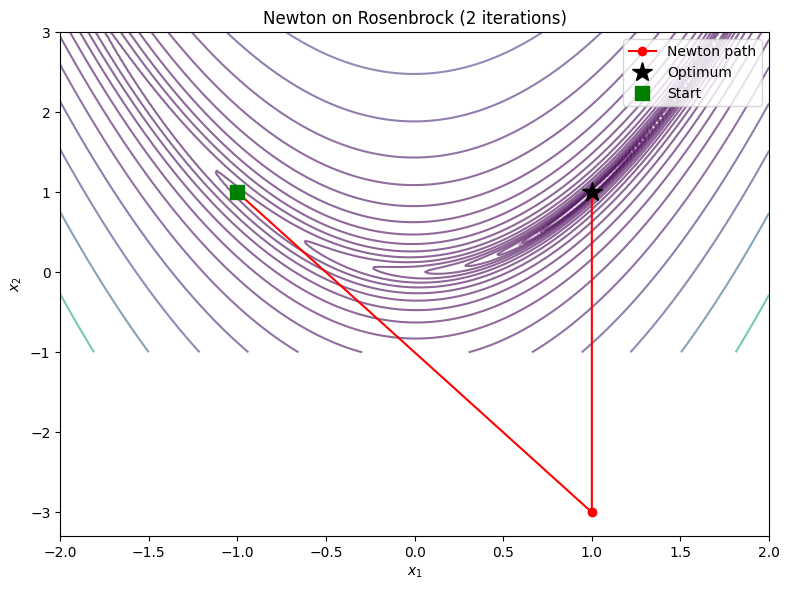

In [8]:
# Visualize Newton's path on Rosenbrock
x0 = np.array([-1.0, 1.0])
x_opt, hist = newton_unconstrained(rosenbrock, rosenbrock_grad, rosenbrock_hess, x0)

# Contour plot
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

xx = np.linspace(-2, 2, 200)
yy = np.linspace(-1, 3, 200)
X, Y = np.meshgrid(xx, yy)
Z = 100 * (Y - X**2)**2 + (1 - X)**2

ax.contour(X, Y, Z, levels=np.logspace(-1, 3.5, 20), cmap='viridis', alpha=0.6)

# Plot Newton path
path = np.array([h['x'] for h in hist])
ax.plot(path[:, 0], path[:, 1], 'ro-', markersize=6, linewidth=1.5, label='Newton path')
ax.plot(1, 1, 'k*', markersize=15, label='Optimum')
ax.plot(path[0, 0], path[0, 1], 'gs', markersize=10, label='Start')

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title(f'Newton on Rosenbrock ({len(hist)-1} iterations)')
ax.legend()
plt.tight_layout()
plt.show()

## What We've Learned

1. Newton's method builds a quadratic model and solves $H d = -g$ at each step
2. It converges **quadratically** near the solution — incredibly fast
3. But it can **diverge** from poor starting points (no globalization)
4. It requires the **exact Hessian**, which is expensive
5. It fails when the Hessian is **indefinite** (near saddle points)

## What's Next

In Note 2, we fix the divergence problem with a **line search** (don't take the full step — find a good step length) and the Hessian cost problem with **quasi-Newton methods** (BFGS) that approximate the Hessian from gradient information.

---

*This is Optimization Note 1 in a series building from Newton's method to the interior point optimizer [ripopt](https://github.com/jkitchin/ripopt).*